Template EDA script for a simple Python-based EDA workflow.

In [ ]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#agregar dataset a muestrear
df = pd.read_csv(r"C:\Users\alan-\OneDrive\Escritorio\TareaData-science\data\2011\records.csv", index_col=False)

In [ ]:
df.head()

,Open Contracting ID,compiledRelease/id,compiledRelease/tender/id,compiledRelease/tender/title,compiledRelease/tender/status,compiledRelease/tender/awardCriteria,compiledRelease/tender/awardCriteriaDetails,compiledRelease/tender/submissionMethod,compiledRelease/tender/bidOpening/date,compiledRelease/tender/bidOpening/address/streetAddress,...,compiledRelease/planning/identifier,compiledRelease/planning/estimatedDate,compiledRelease/planning/budget/description,compiledRelease/planning/budget/amount/currency,compiledRelease/planning/budget/amount/amount,compiledRelease/tag,compiledRelease/tender/techniques/hasElectronicAuction,compiledRelease/tender/contractPeriod/maxExtentDate,compiledRelease/tender/coveredBy,compiledRelease/tender/numberOfTenderers
0,ocds-03ad3f-204835-1,204835-compra-medicamentos-1294743765,204835-compra-medicamentos,COMPRA DE MEDICAMENTOS,complete,priceOnly,Por Lote,inPerson,2010-12-03T07:15:00-04:00,Gobernacion del Caaguazu,...,204835.0,2010-10-31T00:00:00-04:00,COMPRA DE MEDICAMENTOS,PYG,320000000.0,compiled,NaN,NaN,NaN,NaN
1,ocds-03ad3f-206441-1,206441-adquisicion-papel-p-uso-oficina-ad-ref-...,206441-adquisicion-papel-p-uso-oficina-ad-ref,ADQUISICIÓN DE PAPEL P/USO EN OFICINA Ad Ref.,complete,priceOnly,Por Total,inPerson,2010-12-22T12:00:00-04:00,municipalidad de pedro juan caballero,...,206441.0,2010-12-31T00:00:00-04:00,ADQUISICIÓN DE PRODUCTOS DE PAPEL Y CARTÓN,PYG,6000000.0,compiled,NaN,NaN,NaN,NaN
2,ocds-03ad3f-196208-1,196208-adquisicion-desmalezadoras-motosierras-...,196208-adquisicion-desmalezadoras-motosierras-...,"ADQUISICION DE DESMALEZADORAS, MOTOSIERRAS Y F...",complete,priceOnly,Por Total,inPerson,2010-10-07T10:15:00-04:00,SALA DE REUNIONES DE LA DIRECCION DE ADQUISICI...,...,196208.0,2010-09-30T00:00:00-04:00,"ADQUISICION DE DESMALEZADORAS, MOTOSIERRAS Y F...",PYG,88200000.0,compiled,NaN,NaN,NaN,NaN
3,ocds-03ad3f-206008-1,206008-servicios-confeccion-colocacion-pasacal...,206008-servicios-confeccion-colocacion-pasacalles,SERVICIOS DE CONFECCION Y COLOCACION DE PASACA...,complete,priceOnly,Por Total,inPerson,2010-12-29T09:30:00-04:00,"Municipalidad de Ciudad del Este, oficina UOC",...,206008.0,2011-01-31T00:00:00-04:00,SERVICIOS DE CONFECCION DE PASACALLES,PYG,120000000.0,compiled,NaN,NaN,NaN,NaN
4,ocds-03ad3f-205258-1,205258-construcciones-verjas-institucion-12946...,205258-construcciones-verjas-institucion,Construcciones de Verjas para la Institucion,complete,priceOnly,Por Lote,inPerson,2010-11-29T07:30:00-04:00,municipalidad de guarambare,...,205258.0,2010-11-30T00:00:00-04:00,Construcciones de Verjas para la Institucion,PYG,20000000.0,compiled,NaN,NaN,NaN,NaN


renombrar columans para mayor legibilidad

In [ ]:
def clean_data(df):
    df = df.rename(columns={
        'Open Contracting ID': 'id_contratacion_abierta',
        'compiledRelease/id': 'id_liberacion_compilada',
        'compiledRelease/tender/id': 'id_licitacion',
        'compiledRelease/tender/title': 'titulo_licitacion',
        'compiledRelease/tender/status': 'estado_licitacion',
        'compiledRelease/tender/awardCriteria': 'criterio_adjudicacion',
        'compiledRelease/tender/awardCriteriaDetails': 'detalles_criterio_adjudicacion',
        'compiledRelease/tender/submissionMethod': 'metodo_presentacion_licitacion',
        'compiledRelease/tender/bidOpening/date': 'fecha_apertura_ofertas',
        'compiledRelease/tender/bidOpening/address/streetAddress': 'direccion_apertura_ofertas',
        'compiledRelease/tender/submissionMethodDetails': 'detalles_metodo_presentacion',
        'compiledRelease/tender/eligibilityCriteria': 'criterios_elegibilidad',
        'compiledRelease/tender/statusDetails': 'detalles_estado_licitacion',
        'compiledRelease/tender/enquiriesAddress/streetAddress': 'direccion_consultas',
        'compiledRelease/tender/mainProcurementCategoryDetails': 'detalles_categoria_principal',
        'compiledRelease/tender/hasEnquiries': 'tiene_consultas',
        'compiledRelease/tender/value/amount': 'monto_licitacion',
        'compiledRelease/tender/value/currency': 'moneda_licitacion',
        'compiledRelease/tender/datePublished': 'fecha_publicacion_licitacion',
        'compiledRelease/tender/tenderPeriod/startDate': 'fecha_inicio_periodo_licitacion',
        'compiledRelease/tender/tenderPeriod/endDate': 'fecha_fin_periodo_licitacion',
        'compiledRelease/tender/tenderPeriod/durationInDays': 'duracion_periodo_licitacion_dias',
        'compiledRelease/tender/awardPeriod/startDate': 'fecha_inicio_periodo_adjudicacion',
        'compiledRelease/tender/contractPeriod/durationInDays': 'duracion_periodo_contrato_dias',
        'compiledRelease/tender/enquiryPeriod/endDate': 'fecha_fin_periodo_consultas',
        'compiledRelease/tender/enquiryPeriod/startDate': 'fecha_inicio_periodo_consultas',
        'compiledRelease/tender/enquiryPeriod/durationInDays': 'duracion_periodo_consultas_dias',
        'compiledRelease/tender/mainProcurementCategory': 'categoria_principal_contratacion',
        'compiledRelease/tender/additionalProcurementCategories': 'categorias_adicionales_contratacion',
        'compiledRelease/tender/procurementMethod': 'metodo_contratacion',
        'compiledRelease/tender/procurementMethodDetails': 'detalles_metodo_contratacion',
        'compiledRelease/tender/procuringEntity/id': 'id_entidad_contratante',
        'compiledRelease/tender/procuringEntity/name': 'nombre_entidad_contratante',
        'compiledRelease/language': 'idioma',
        'compiledRelease/ocid': 'ocid',
        'compiledRelease/date': 'fecha_liberacion',
        'compiledRelease/initiationType': 'tipo_iniciacion',
        'compiledRelease/buyer/id': 'id_comprador',
        'compiledRelease/buyer/name': 'nombre_comprador',
        'compiledRelease/planning/identifier': 'identificador_planificacion',
        'compiledRelease/planning/estimatedDate': 'fecha_estimada_planificacion',
        'compiledRelease/planning/budget/description': 'descripcion_presupuesto',
        'compiledRelease/planning/budget/amount/currency': 'moneda_presupuesto',
        'compiledRelease/planning/budget/amount/amount': 'monto_presupuesto',
        'compiledRelease/tag': 'etiqueta',
        'compiledRelease/tender/techniques/hasElectronicAuction': 'tiene_subasta_electronica',
        'compiledRelease/tender/contractPeriod/maxExtentDate': 'fecha_maxima_extension_contrato',
        'compiledRelease/tender/coveredBy': 'cubierto_por',
        'compiledRelease/tender/numberOfTenderers': 'cantidad_oferentes'
    })
    return df

df = pd.read_csv(r'c:\Users\alan-\OneDrive\Escritorio\TareaData-science\data\2011\records.csv')

df = clean_data(df.copy())
df.head()

,id_contratacion_abierta,id_liberacion_compilada,id_licitacion,titulo_licitacion,estado_licitacion,criterio_adjudicacion,detalles_criterio_adjudicacion,metodo_presentacion_licitacion,fecha_apertura_ofertas,direccion_apertura_ofertas,...,identificador_planificacion,fecha_estimada_planificacion,descripcion_presupuesto,moneda_presupuesto,monto_presupuesto,etiqueta,tiene_subasta_electronica,fecha_maxima_extension_contrato,cubierto_por,cantidad_oferentes
0,ocds-03ad3f-204835-1,204835-compra-medicamentos-1294743765,204835-compra-medicamentos,COMPRA DE MEDICAMENTOS,complete,priceOnly,Por Lote,inPerson,2010-12-03T07:15:00-04:00,Gobernacion del Caaguazu,...,204835.0,2010-10-31T00:00:00-04:00,COMPRA DE MEDICAMENTOS,PYG,320000000.0,compiled,NaN,NaN,NaN,NaN
1,ocds-03ad3f-206441-1,206441-adquisicion-papel-p-uso-oficina-ad-ref-...,206441-adquisicion-papel-p-uso-oficina-ad-ref,ADQUISICIÓN DE PAPEL P/USO EN OFICINA Ad Ref.,complete,priceOnly,Por Total,inPerson,2010-12-22T12:00:00-04:00,municipalidad de pedro juan caballero,...,206441.0,2010-12-31T00:00:00-04:00,ADQUISICIÓN DE PRODUCTOS DE PAPEL Y CARTÓN,PYG,6000000.0,compiled,NaN,NaN,NaN,NaN
2,ocds-03ad3f-196208-1,196208-adquisicion-desmalezadoras-motosierras-...,196208-adquisicion-desmalezadoras-motosierras-...,"ADQUISICION DE DESMALEZADORAS, MOTOSIERRAS Y F...",complete,priceOnly,Por Total,inPerson,2010-10-07T10:15:00-04:00,SALA DE REUNIONES DE LA DIRECCION DE ADQUISICI...,...,196208.0,2010-09-30T00:00:00-04:00,"ADQUISICION DE DESMALEZADORAS, MOTOSIERRAS Y F...",PYG,88200000.0,compiled,NaN,NaN,NaN,NaN
3,ocds-03ad3f-206008-1,206008-servicios-confeccion-colocacion-pasacal...,206008-servicios-confeccion-colocacion-pasacalles,SERVICIOS DE CONFECCION Y COLOCACION DE PASACA...,complete,priceOnly,Por Total,inPerson,2010-12-29T09:30:00-04:00,"Municipalidad de Ciudad del Este, oficina UOC",...,206008.0,2011-01-31T00:00:00-04:00,SERVICIOS DE CONFECCION DE PASACALLES,PYG,120000000.0,compiled,NaN,NaN,NaN,NaN
4,ocds-03ad3f-205258-1,205258-construcciones-verjas-institucion-12946...,205258-construcciones-verjas-institucion,Construcciones de Verjas para la Institucion,complete,priceOnly,Por Lote,inPerson,2010-11-29T07:30:00-04:00,municipalidad de guarambare,...,205258.0,2010-11-30T00:00:00-04:00,Construcciones de Verjas para la Institucion,PYG,20000000.0,compiled,NaN,NaN,NaN,NaN


generar variable target
por ahora tendremos dos targets porque aun no se decide si haremos regresion o clasificacion

In [ ]:
def generar_target_clasificacion(df):
    df['tiene_sobre_costo'] = (df['monto_licitacion'] - df['monto_presupuesto']>0).astype(int)
    return df

def generar_target_regresion(df):
    df['sobre_costo'] = (df['monto_licitacion'] - df['monto_presupuesto'])
    return df

df_clasificacion = generar_target_clasificacion
df_regresion = generar_target_regresion(df)

SyntaxError: invalid syntax (4168640597.py, line 1)

Vista general del dataset

In [ ]:
df.shape
df.head()
df.sample(5)
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11539 entries, 0 to 11538
Data columns (total 49 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id_contratacion_abierta              11539 non-null  object 
 1   id_liberacion_compilada              11539 non-null  object 
 2   id_licitacion                        11539 non-null  object 
 3   titulo_licitacion                    10229 non-null  object 
 4   estado_licitacion                    11539 non-null  object 
 5   criterio_adjudicacion                10117 non-null  object 
 6   detalles_criterio_adjudicacion       10229 non-null  object 
 7   metodo_presentacion_licitacion       9991 non-null   object 
 8   fecha_apertura_ofertas               9357 non-null   object 
 9   direccion_apertura_ofertas           9989 non-null   object 
 10  detalles_metodo_presentacion         9991 non-null   object 
 11  criterios_elegibilidad      

,id_contratacion_abierta,id_liberacion_compilada,id_licitacion,titulo_licitacion,estado_licitacion,criterio_adjudicacion,detalles_criterio_adjudicacion,metodo_presentacion_licitacion,fecha_apertura_ofertas,direccion_apertura_ofertas,...,identificador_planificacion,fecha_estimada_planificacion,descripcion_presupuesto,moneda_presupuesto,monto_presupuesto,etiqueta,tiene_subasta_electronica,fecha_maxima_extension_contrato,cubierto_por,cantidad_oferentes
count,11539,11539,11539,10229,11539,10117,10229,9991,9357,9989,...,10462.000000,10462,10462,10462,1.046200e+04,11539,634,2835,102,4.0
unique,11539,11539,10230,8636,4,4,4,2,4067,4264,...,NaN,91,8612,2,NaN,1,1,72,2,NaN
top,ocds-03ad3f-226673-1,226673-adquisicion-servicio-consultoria-132268...,planned,ADQUISICION DE UTILES DE OFICINA,complete,priceOnly,Por Total,inPerson,2011-01-21T08:10:00-04:00,Sistema SBE,...,NaN,2011-11-30T00:00:00-04:00,ADQUISICION DE MUEBLES Y ENSERES,PYG,NaN,compiled,True,2011-12-31T00:00:00-04:00,adreferendum,NaN
freq,1,1,1310,31,9010,9781,6393,9357,64,596,...,NaN,1386,34,10408,NaN,11539,634,2043,78,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,217111.260849,NaN,NaN,NaN,1.455801e+09,NaN,NaN,NaN,NaN,1.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8006.855897,NaN,NaN,NaN,2.751324e+10,NaN,NaN,NaN,NaN,0.0
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,139900.000000,NaN,NaN,NaN,1.595000e+04,NaN,NaN,NaN,NaN,1.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,210763.000000,NaN,NaN,NaN,2.600000e+07,NaN,NaN,NaN,NaN,1.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,218649.000000,NaN,NaN,NaN,8.500000e+07,NaN,NaN,NaN,NaN,1.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,223857.000000,NaN,NaN,NaN,2.736730e+08,NaN,NaN,NaN,NaN,1.0


Missing values

In [ ]:
df.isnull().mean().sort_values(ascending=False)

cantidad_oferentes                     0.999653
cubierto_por                           0.991160
tiene_subasta_electronica              0.945056
categorias_adicionales_contratacion    0.755611
fecha_maxima_extension_contrato        0.754311
duracion_periodo_contrato_dias         0.370396
fecha_apertura_ofertas                 0.189098
fecha_inicio_periodo_adjudicacion      0.178178
criterios_elegibilidad                 0.143947
duracion_periodo_licitacion_dias       0.143947
fecha_inicio_periodo_licitacion        0.143860
duracion_periodo_consultas_dias        0.143860
fecha_inicio_periodo_consultas         0.143860
direccion_consultas                    0.137880
fecha_fin_periodo_consultas            0.137620
direccion_apertura_ofertas             0.134327
fecha_fin_periodo_licitacion           0.134240
detalles_metodo_presentacion           0.134154
metodo_presentacion_licitacion         0.134154
tiene_consultas                        0.123234
criterio_adjudicacion                  0

Duplicados

In [ ]:
df.duplicated().sum()

np.int64(0)

Cardinalidad

In [ ]:
df.nunique().sort_values()

tiene_subasta_electronica                  1
etiqueta                                   1
tipo_iniciacion                            1
cantidad_oferentes                         1
idioma                                     1
metodo_presentacion_licitacion             2
moneda_licitacion                          2
tiene_consultas                            2
cubierto_por                               2
moneda_presupuesto                         2
metodo_contratacion                        3
categoria_principal_contratacion           3
categorias_adicionales_contratacion        4
criterio_adjudicacion                      4
estado_licitacion                          4
detalles_criterio_adjudicacion             4
detalles_estado_licitacion                 7
detalles_metodo_contratacion              27
criterios_elegibilidad                    32
detalles_categoria_principal              40
fecha_maxima_extension_contrato           72
fecha_estimada_planificacion              91
duracion_p

Analisis univariado(Analisis sobre cada feature)

In [ ]:
features_numericas = [
    'monto_licitacion',
    'duracion_periodo_licitacion_dias',
    'duracion_periodo_contrato_dias',
    'duracion_periodo_consultas_dias',
    'monto_presupuesto',
    'cantidad_oferentes'
]

Histograma y descripcion de monto_licitacion


count    1.011700e+04
mean     9.044186e+08
std      1.620940e+10
min      0.000000e+00
25%      2.450000e+07
50%      7.999999e+07
75%      2.600172e+08
max      1.456100e+12
Name: monto_licitacion, dtype: float64

Histograma y descripcion de monto_licitacion


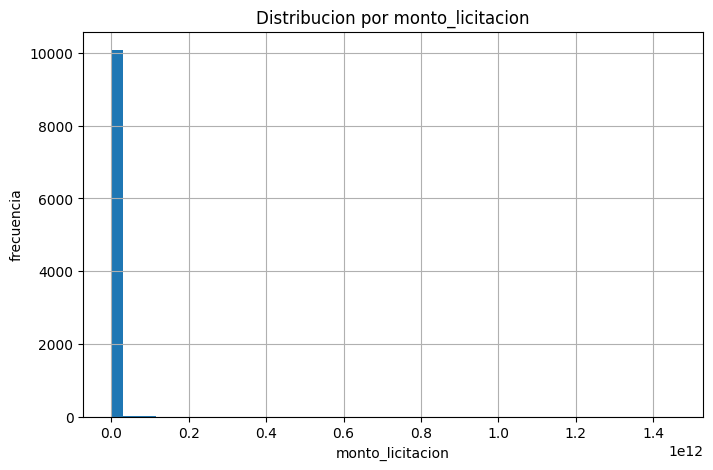

Histograma y descripcion de duracion_periodo_licitacion_dias


count    9878.000000
mean       13.296518
std        12.525178
min      -253.000000
25%         7.000000
50%        11.000000
75%        16.000000
max       232.000000
Name: duracion_periodo_licitacion_dias, dtype: float64

Histograma y descripcion de duracion_periodo_licitacion_dias


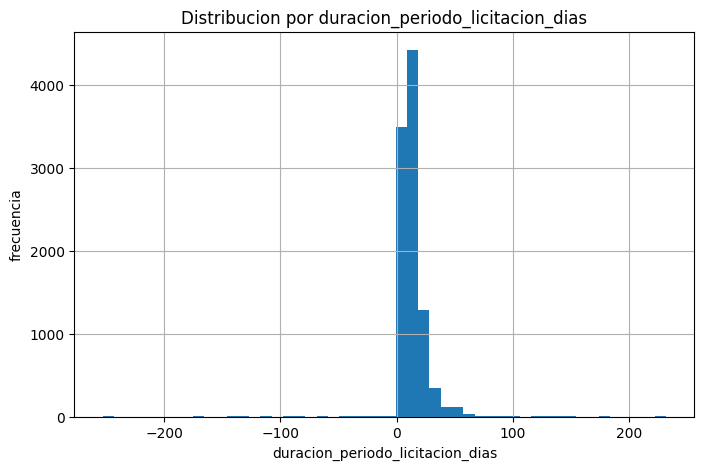

Histograma y descripcion de duracion_periodo_contrato_dias


count     7265.000000
mean       199.896765
std        334.444397
min          0.000000
25%         60.000000
50%        120.000000
75%        360.000000
max      21900.000000
Name: duracion_periodo_contrato_dias, dtype: float64

Histograma y descripcion de duracion_periodo_contrato_dias


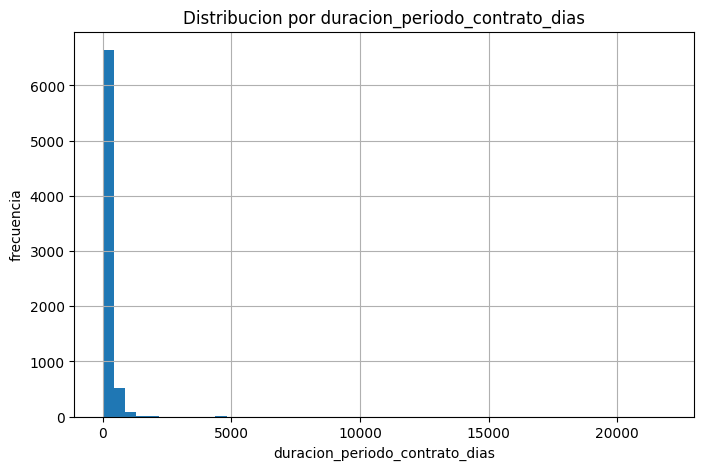

Histograma y descripcion de duracion_periodo_consultas_dias


count    9879.000000
mean        7.005770
std        10.118365
min      -253.000000
25%         2.000000
50%         5.000000
75%         9.000000
max       225.000000
Name: duracion_periodo_consultas_dias, dtype: float64

Histograma y descripcion de duracion_periodo_consultas_dias


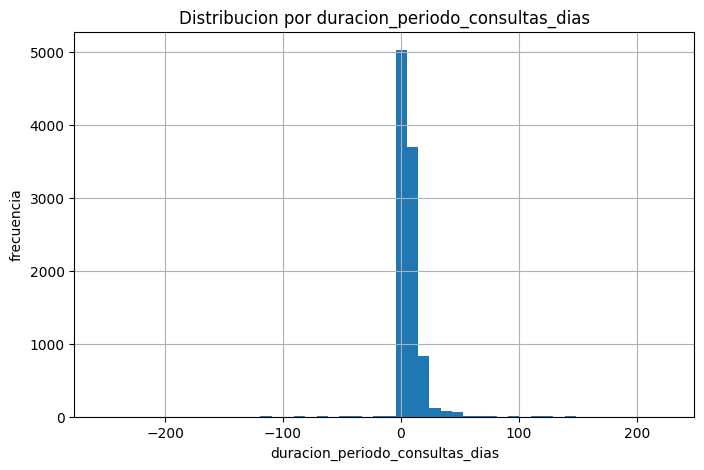

Histograma y descripcion de monto_presupuesto


count    1.046200e+04
mean     1.455801e+09
std      2.751324e+10
min      1.595000e+04
25%      2.600000e+07
50%      8.500000e+07
75%      2.736730e+08
max      1.645000e+12
Name: monto_presupuesto, dtype: float64

Histograma y descripcion de monto_presupuesto


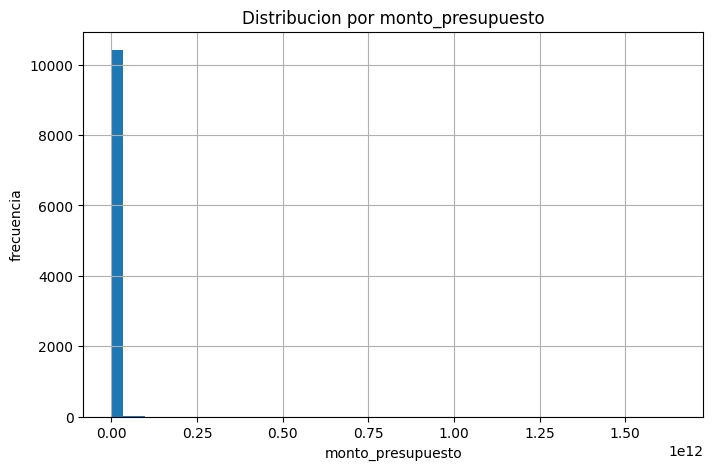

Histograma y descripcion de cantidad_oferentes


count    4.0
mean     1.0
std      0.0
min      1.0
25%      1.0
50%      1.0
75%      1.0
max      1.0
Name: cantidad_oferentes, dtype: float64

Histograma y descripcion de cantidad_oferentes


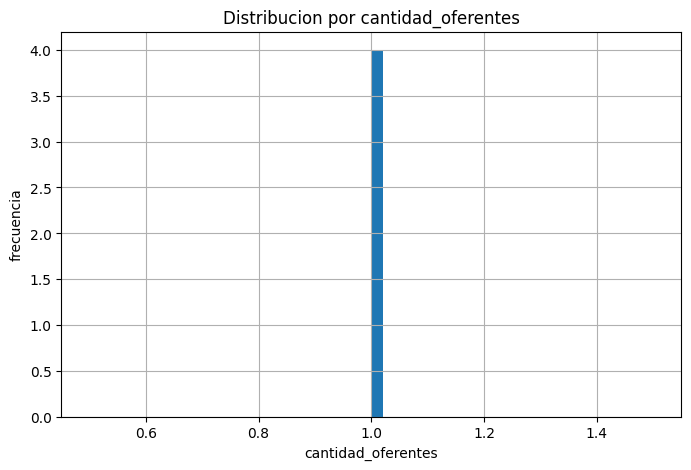

In [ ]:
#features Numericas
for col in features_numericas:
    print(f"Histograma y descripcion de {col}")
    #descripcion
    display(df[col].describe())


    print(f"Histograma y descripcion de {col}")
    plt.figure(figsize=(8,5))
    df[col].hist(bins=50)
    plt.title(f"Distribucion por {col}")
    plt.xlabel(col)
    plt.ylabel("frecuencia")
    plt.show()

#features Categóricas
# df[col].value_counts(normalize=True)
# df[col].value_counts(normalize=True).plot(kind='bar')

Relacion con el target

In [ ]:
#regresion
#cambiar target por la columna que se quiera predecir
# df.corr(numeric_only=True)['target']

#para clasificacion
#opcion 1
# sns.boxplot(x=target, y=feature)
#opcion 2
# pd.crosstab(df[col], df[target], normalize='index')

#grafico
# plt.scatter(df[col], df[target])

Relaciones entre variables

In [ ]:
sns.heatmap(df.corr())

ValueError: could not convert string to float: 'ocds-03ad3f-204835-1'

Cosas a tener en cuenta:
-Leakage
-Drift temporal

In [ ]:
corrs = df.corr(numeric_only=True)["target"].abs()

suspicious = corrs[corrs > 0.95].sort_values(ascending=False)

print(suspicious)

from sklearn.metrics import roc_auc_score

for col in numeric_cols:
    try:
        auc = roc_auc_score(df["target"], df[col])
        if auc > 0.95 or auc < 0.05:
            print(col, auc)
    except:
        pass

Desbalanceo de los valores en la columna a predecir

In [ ]:
df[target].value_counts(normalize=True)

Ydata-profiling

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df)
profile.to_notebook_iframe()